In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt

from resilient_rover.envs.line_world_env import LineWorldEnv

In [2]:
env = LineWorldEnv()

observation, info = env.reset(seed=42)

terminated = False
truncated = False
total_reward = 0

while not terminated and not truncated:
    action = env.action_space.sample()

    observation, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    
    print(
        f"Action: {action}, "
        f"Observation: {observation}. "
        f"Reward: {reward}"
    )

print(f"Episode reward: {total_reward}")

Action: 2, Observation: {'rover': 0, 'target': 7, 'battery': 19}. Reward: -1
Action: 0, Observation: {'rover': 0, 'target': 7, 'battery': 18}. Reward: -1
Action: 1, Observation: {'rover': 1, 'target': 7, 'battery': 17}. Reward: -1
Action: 0, Observation: {'rover': 1, 'target': 7, 'battery': 16}. Reward: -1
Action: 0, Observation: {'rover': 1, 'target': 7, 'battery': 15}. Reward: -1
Action: 1, Observation: {'rover': 2, 'target': 7, 'battery': 14}. Reward: -1
Action: 0, Observation: {'rover': 2, 'target': 7, 'battery': 13}. Reward: -1
Action: 1, Observation: {'rover': 3, 'target': 7, 'battery': 12}. Reward: -1
Action: 0, Observation: {'rover': 3, 'target': 7, 'battery': 11}. Reward: -1
Action: 1, Observation: {'rover': 4, 'target': 7, 'battery': 10}. Reward: -1
Action: 2, Observation: {'rover': 3, 'target': 7, 'battery': 9}. Reward: -1
Action: 2, Observation: {'rover': 2, 'target': 7, 'battery': 8}. Reward: -1
Action: 2, Observation: {'rover': 1, 'target': 7, 'battery': 7}. Reward: -1
Ac

In [3]:
num_episodes = 10

for episode in range(num_episodes):
    observation, info = env.reset()

    terminated = False
    truncated = False
    total_reward = 0
    step_count = 0

    while not terminated and not truncated:
        action = env.action_space.sample()

        observation, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        step_count += 1
    
    print(
        f"Episode: {episode + 1}, "
        f"Reward: {total_reward}, "
        f"Terminated: {terminated}, "
        f"Truncated: {truncated}"
    )


Episode: 1, Reward: -15, Terminated: False, Truncated: True
Episode: 2, Reward: 90, Terminated: True, Truncated: False
Episode: 3, Reward: -15, Terminated: False, Truncated: True
Episode: 4, Reward: -15, Terminated: False, Truncated: True
Episode: 5, Reward: 92, Terminated: True, Truncated: False
Episode: 6, Reward: 97, Terminated: True, Truncated: False
Episode: 7, Reward: -15, Terminated: False, Truncated: True
Episode: 8, Reward: 98, Terminated: True, Truncated: False
Episode: 9, Reward: 94, Terminated: True, Truncated: False
Episode: 10, Reward: 98, Terminated: True, Truncated: False


In [4]:
num_episodes = 1000

# Use seed for reproducibility for both environment and action space starting states
seed = 42

env = LineWorldEnv()
env.action_space.seed(seed)

successes = 0
failures = 0
truncations = 0

total_rewards = []
episode_lengths = []
battery_remaining_on_success = []

for episode in range(num_episodes):

    if episode == 0:
        observation, info = env.reset(seed=seed)
    else:
        observation, info = env.reset()

    terminated = False
    truncated = False
    total_reward = 0
    step_count = 0

    while not terminated and not truncated:
        action = env.action_space.sample()

        observation, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        step_count += 1

    # Classify the episode outcome
    # Save total_reward
    total_rewards.append(total_reward)

    # Save step_count
    episode_lengths.append(step_count)

    # If successful, save remaining battery
    if observation["rover"] == observation["target"]:
        successes += 1
        battery_remaining_on_success.append(observation["battery"])

    elif observation["battery"] <= 0:
        failures += 1

    elif truncated:
        truncations += 1

assert successes + failures + truncations == num_episodes

In [9]:
success_rate = successes / num_episodes
failure_rate = failures / num_episodes
truncation_rate = truncations / num_episodes

average_reward = sum(total_rewards) / len(total_rewards)
average_episode_length = sum(episode_lengths) / len(episode_lengths)

# Take potential zero successes into account
if battery_remaining_on_success:
    average_battery_on_success = (sum(battery_remaining_on_success) / len(battery_remaining_on_success))
else:
    average_battery_on_success = 0

print(f"Success rate: {success_rate:.1%}")
print(f"Failure rate: {failure_rate:.1%}")
print(f"Truncation rate: {truncation_rate:.1%}")
print(f"Average reward: {average_reward:.2f}")
print(f"Average episode length: {average_episode_length:.2f}")
print(f"Average battery remaining on success: {average_battery_on_success:.2f}")

Success rate: 37.6%
Failure rate: 0.0%
Truncation rate: 62.4%
Average reward: 26.26
Average episode length: 11.71
Average battery remaining on success: 13.74


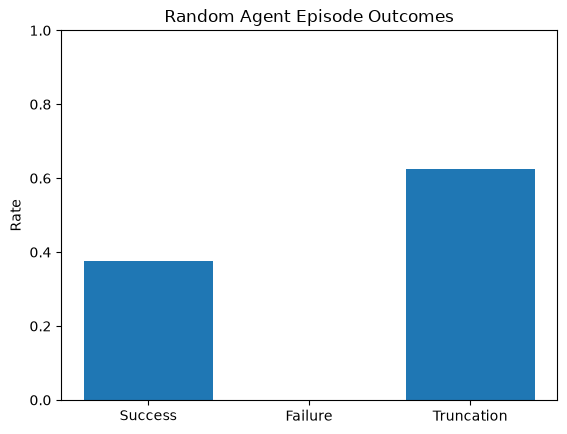

In [6]:
outcomes = ["Success", "Failure", "Truncation"]
rates = [success_rate, failure_rate, truncation_rate]

plt.bar(outcomes, rates)
plt.title("Random Agent Episode Outcomes")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.show()


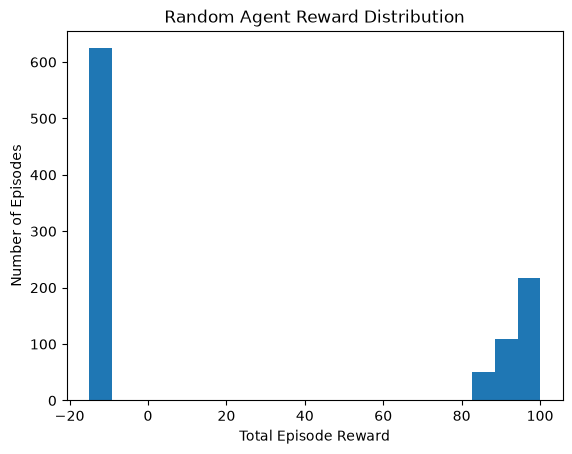

In [7]:
plt.hist(total_rewards, bins=20)
plt.xlabel("Total Episode Reward")
plt.ylabel("Number of Episodes")
plt.title("Random Agent Reward Distribution")
plt.show()

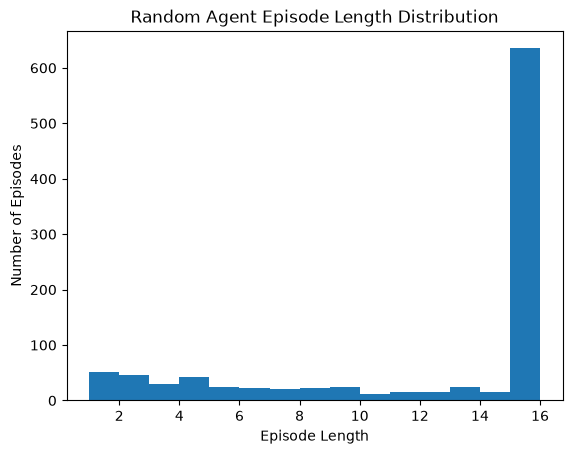

In [8]:
plt.hist(episode_lengths, bins=range(1, max(episode_lengths) + 2))
plt.xlabel("Episode Length")
plt.ylabel("Number of Episodes")
plt.title("Random Agent Episode Length Distribution")
plt.show()

## Baseline Interpretation

How often does the random agent succeed?
The random agent succeeds approximately 38% of the time.

How often does it hit the step limit?
The random agent hits the step limit causing a truncation of the episode about 62% of the time. This high number may be partially explained by the fact that the step limit is set lower than the number of battery level units and so it therefore will never terminate an episode due to a depleted battery.

What does the reward distribution look like?
The reward distribution has two distinguishable groups. Truncated episodes cluster at -15 because they use up the full 15-step limit without ever reaching the target. Successful episodes seem to generally receive rewards in the 80-100 range, depending on how many steps were required for the rover to reach the target.

What should a trained Q-learning agent clearly improve upon?
The success rate and average reward should both be substantially higher for a Q-learning agent than for the random agent. It should also reduce the episode length by learning to consistently move toward the target instead of waiting or moving in the wrong direction.